In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

plt.style.use('ggplot')

In [2]:
df = pd.read_csv('Data/ai_human_content_detection_dataset.csv')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1367 entries, 0 to 1366
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   text_content          1367 non-null   str    
 1   content_type          1367 non-null   str    
 2   word_count            1367 non-null   int64  
 3   character_count       1367 non-null   int64  
 4   sentence_count        1367 non-null   int64  
 5   lexical_diversity     1367 non-null   float64
 6   avg_sentence_length   1367 non-null   float64
 7   avg_word_length       1367 non-null   float64
 8   punctuation_ratio     1367 non-null   float64
 9   flesch_reading_ease   1288 non-null   float64
 10  gunning_fog_index     1332 non-null   float64
 11  grammar_errors        1367 non-null   int64  
 12  passive_voice_ratio   1336 non-null   float64
 13  predictability_score  1367 non-null   float64
 14  burstiness            1367 non-null   float64
 15  sentiment_score       1313 non-n

In [3]:
df.isnull().sum()

text_content             0
content_type             0
word_count               0
character_count          0
sentence_count           0
lexical_diversity        0
avg_sentence_length      0
avg_word_length          0
punctuation_ratio        0
flesch_reading_ease     79
gunning_fog_index       35
grammar_errors           0
passive_voice_ratio     31
predictability_score     0
burstiness               0
sentiment_score         54
label                    0
dtype: int64

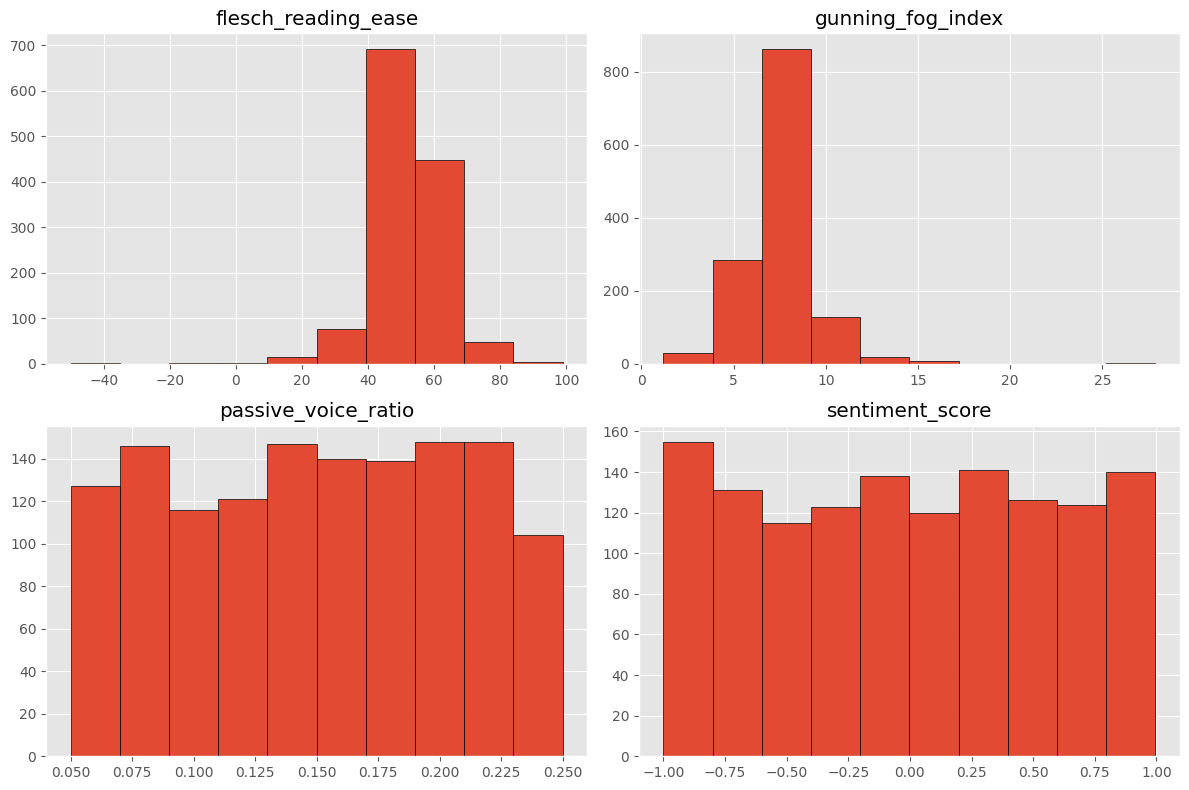

In [4]:
feat_to_check = ['flesch_reading_ease' , 'gunning_fog_index', 'passive_voice_ratio',
                 'sentiment_score']

plt.figure(figsize = (12, 8))

for count, ele in enumerate(feat_to_check):
    plt.subplot(2, 2, count + 1)
    df[ele].hist(edgecolor = 'black')
    plt.title(ele)

plt.tight_layout()
plt.show()


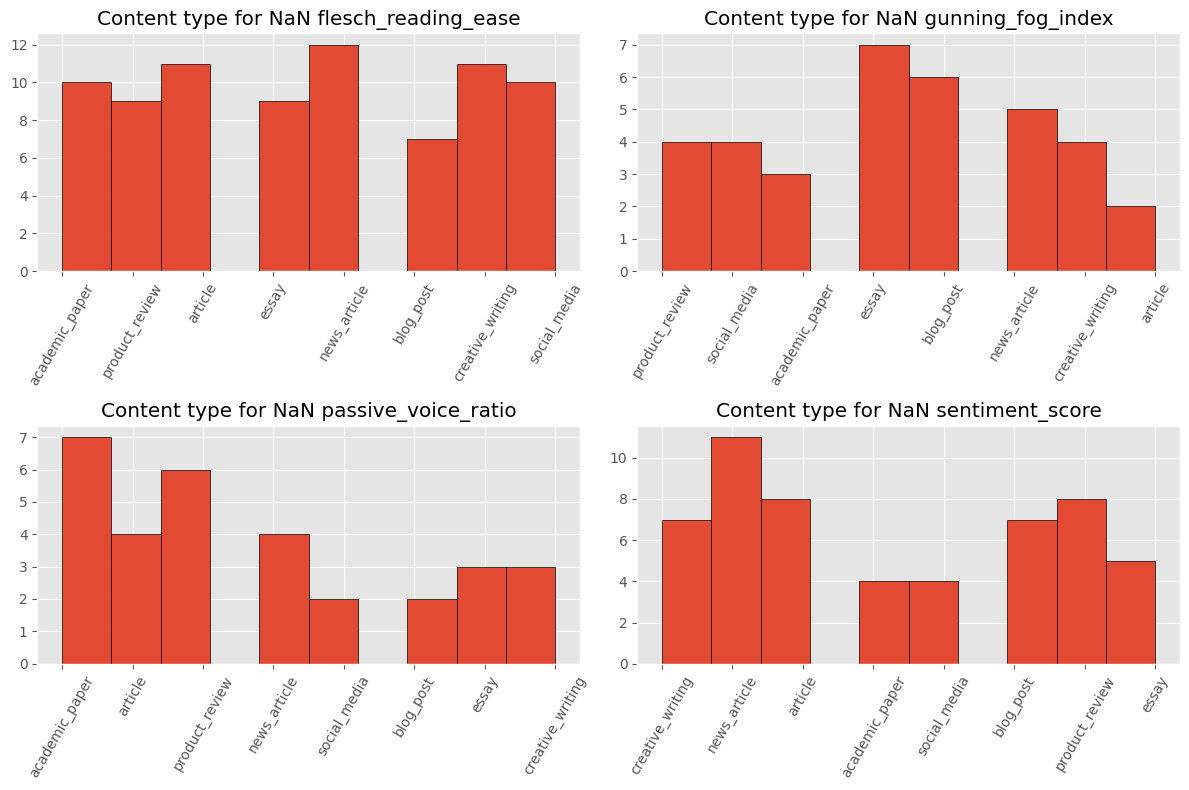

In [5]:
plt.figure(figsize = (12, 8))

for count, ele in enumerate(feat_to_check):
    plt.subplot(2, 2, count + 1)
    df[df[ele].isna()]['content_type'].hist(edgecolor = 'black')
    plt.title(f'Content type for NaN {ele}')
    plt.xticks(rotation = 60)

plt.tight_layout()
plt.show()

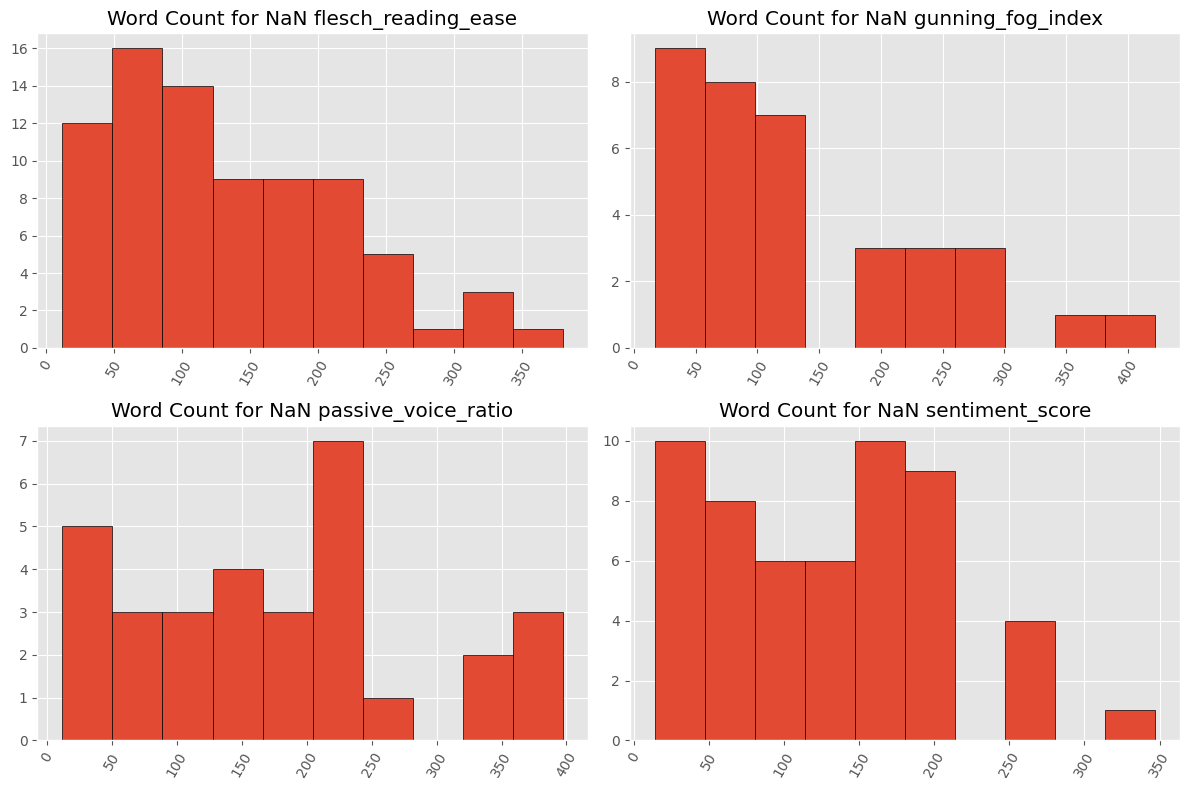

In [6]:
plt.figure(figsize = (12, 8))

for count, ele in enumerate(feat_to_check):
    plt.subplot(2, 2, count + 1)
    df[df[ele].isna()]['word_count'].hist(edgecolor = 'black')
    plt.title(f'Word Count for NaN {ele}')
    plt.xticks(rotation = 60)

plt.tight_layout()
plt.show()

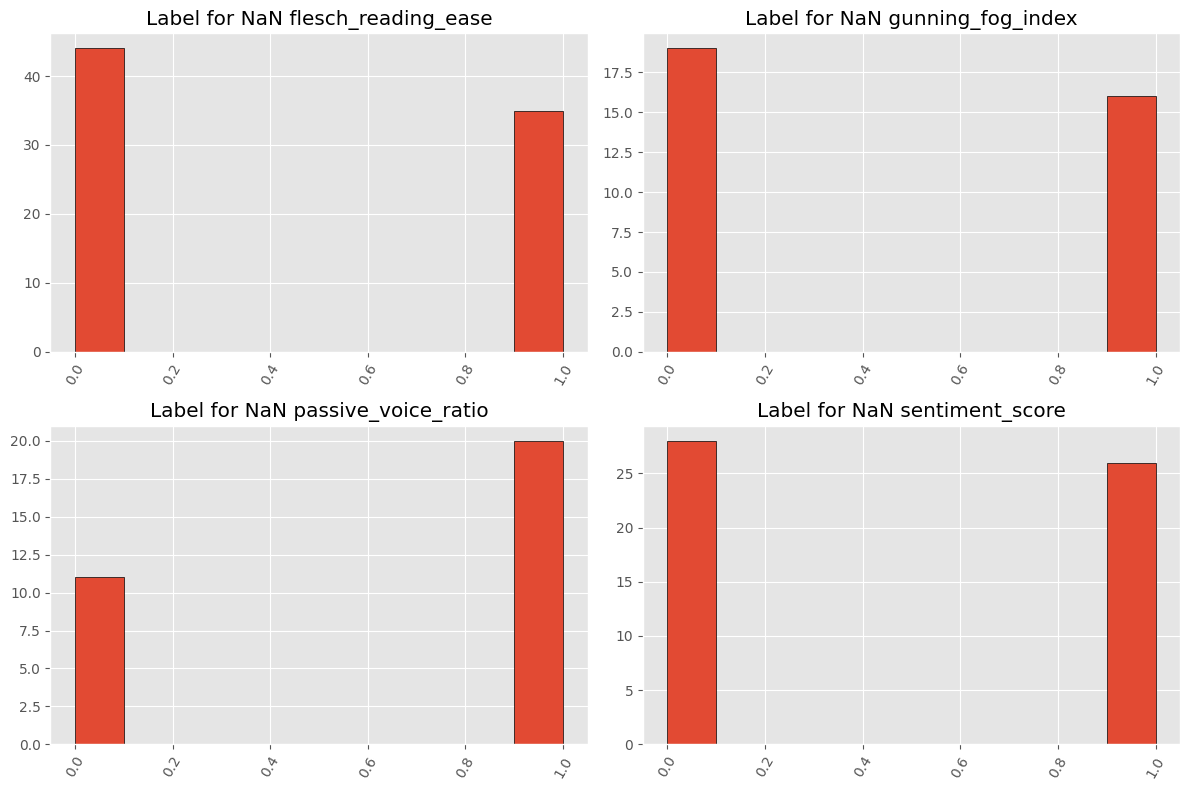

In [7]:
plt.figure(figsize = (12, 8))

for count, ele in enumerate(feat_to_check):
    plt.subplot(2, 2, count + 1)
    df[df[ele].isna()]['label'].hist(edgecolor = 'black')
    plt.title(f'Label for NaN {ele}')
    plt.xticks(rotation = 60)

plt.tight_layout()
plt.show()

The `Missing Values` seems to be **at random** and scatter across multiple type. We will use *median impute* for most of them, with the exception of `sentiment_score`. My line of thinking is that null for `sentiment_score` is that the model couldn't detect emotion, so we will set them to **0** 

In [8]:
median_cols = ['flesch_reading_ease', 'gunning_fog_index', 'passive_voice_ratio']

for col in median_cols:
    df[col] = df[col].fillna(df[col].median())

df['sentiment_score'] = df['sentiment_score'].fillna(0)

## EDA

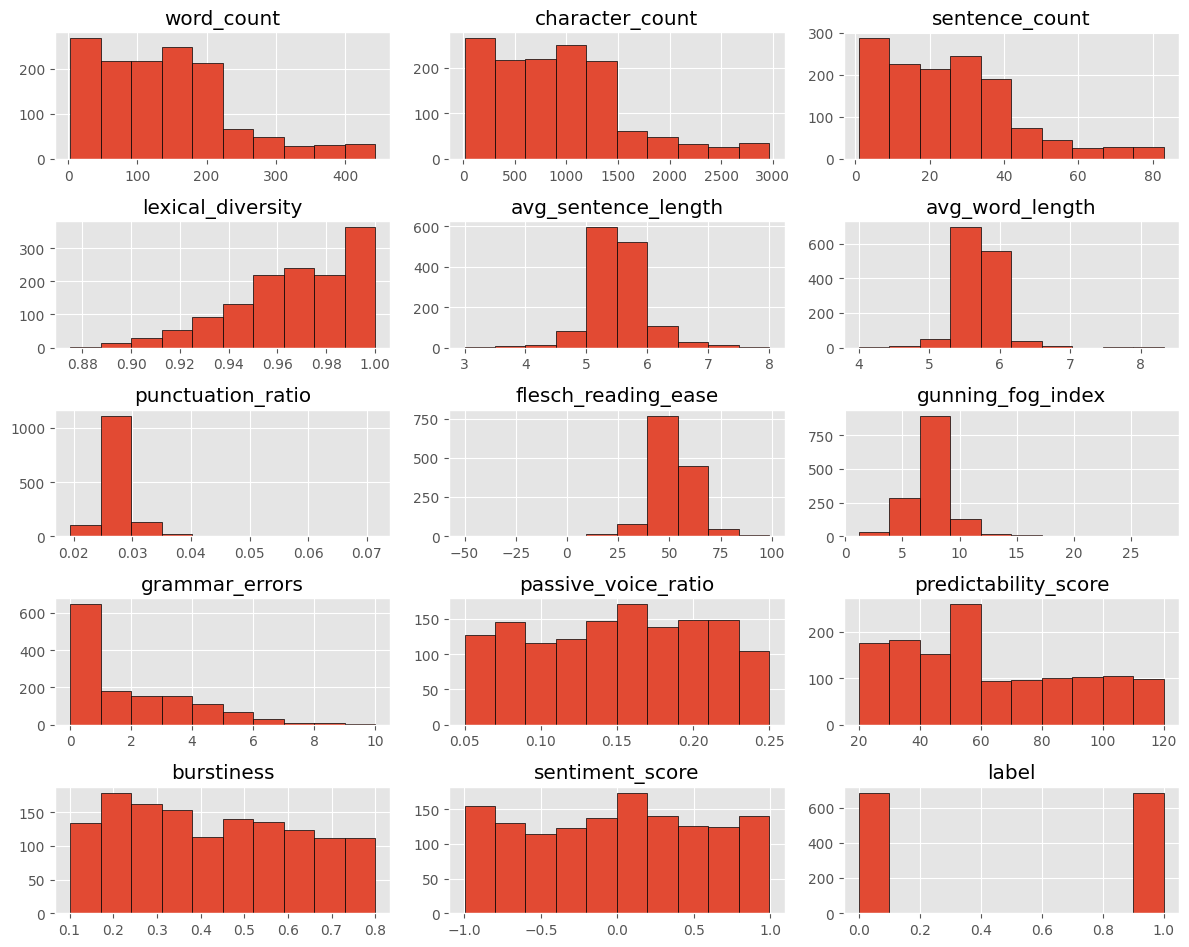

In [9]:
num_feat = df.select_dtypes(exclude= ['str']).columns

n_per_col = 3
row = (len(num_feat) // n_per_col) + n_per_col
plt.figure(figsize= (12, 15))

for count, ele in enumerate(num_feat):
    plt.subplot(row, n_per_col, count + 1)
    df[ele].hist(edgecolor = 'black')
    plt.title(ele)

plt.tight_layout()
plt.show()


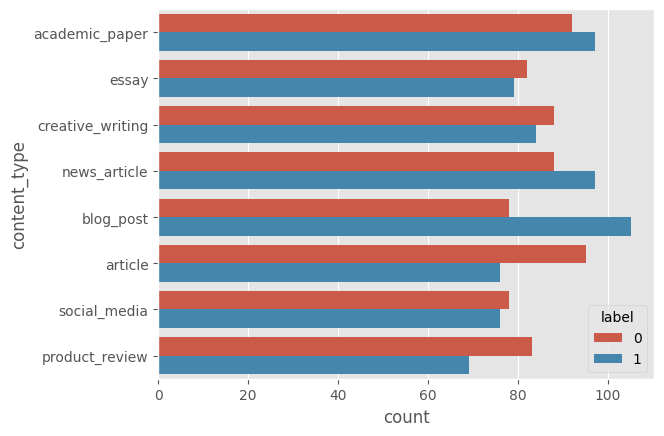

In [10]:
sns.countplot(df, y = 'content_type', hue = 'label')
plt.show()

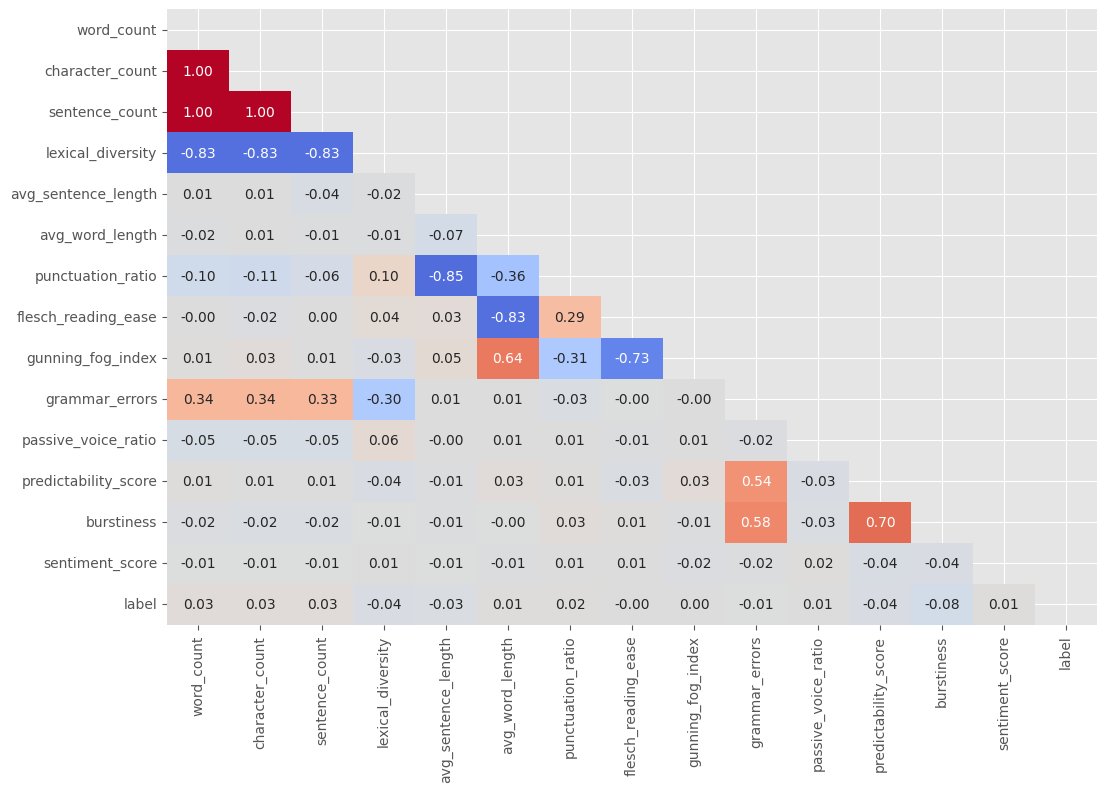

In [11]:
matrix = df[num_feat].corr()

mask = np.triu(np.ones_like(matrix, dtype= bool))

plt.figure(figsize = (12, 8))
sns.heatmap(matrix, mask= mask, cbar = False, center = 0, cmap = 'coolwarm',
            annot = True, fmt = '.2f')

plt.show()

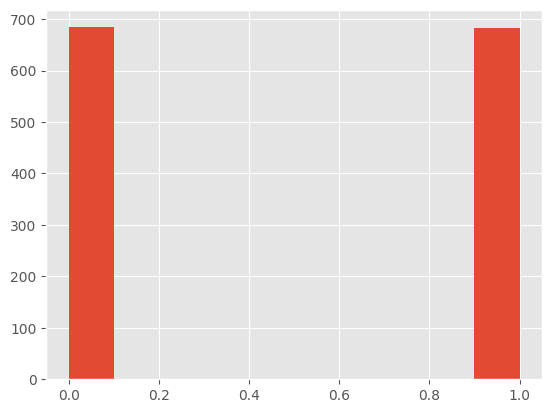

In [12]:
df['label'].hist()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['text_content', 'label']).copy()
y = df['label'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size= 0.8, random_state= 8,stratify= y)

print(X_train.shape, X_test.shape)

(1093, 15) (274, 15)


In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC

num_col = X_train.select_dtypes(exclude=['str']).columns
label_col = ['content_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('label',OneHotEncoder(), label_col),
        ('scaler', StandardScaler(), num_col)
    ]
)


models = {
    'base' : Pipeline([
        ('preprocess', preprocessor),
        ('model', LogisticRegression())
    ]),

    'xgb' : Pipeline([
        ('preprocess', preprocessor),
        ('model', XGBClassifier(
            n_estimators = 200,
            random_state = 8
        ))
    ]),

    'svm' : Pipeline([
        ('preprocess', preprocessor),
        ('model', SVC(kernel='rbf', probability=True, random_state = 8))
    ]),

}

In [15]:
preds = {}

for name, model in models.items():
    print(f'Training and predicting {name} ----\n')
    model.fit(X_train, y_train)
    preds[name] = model.predict(X_test)



Training and predicting base ----

Training and predicting xgb ----

Training and predicting svm ----



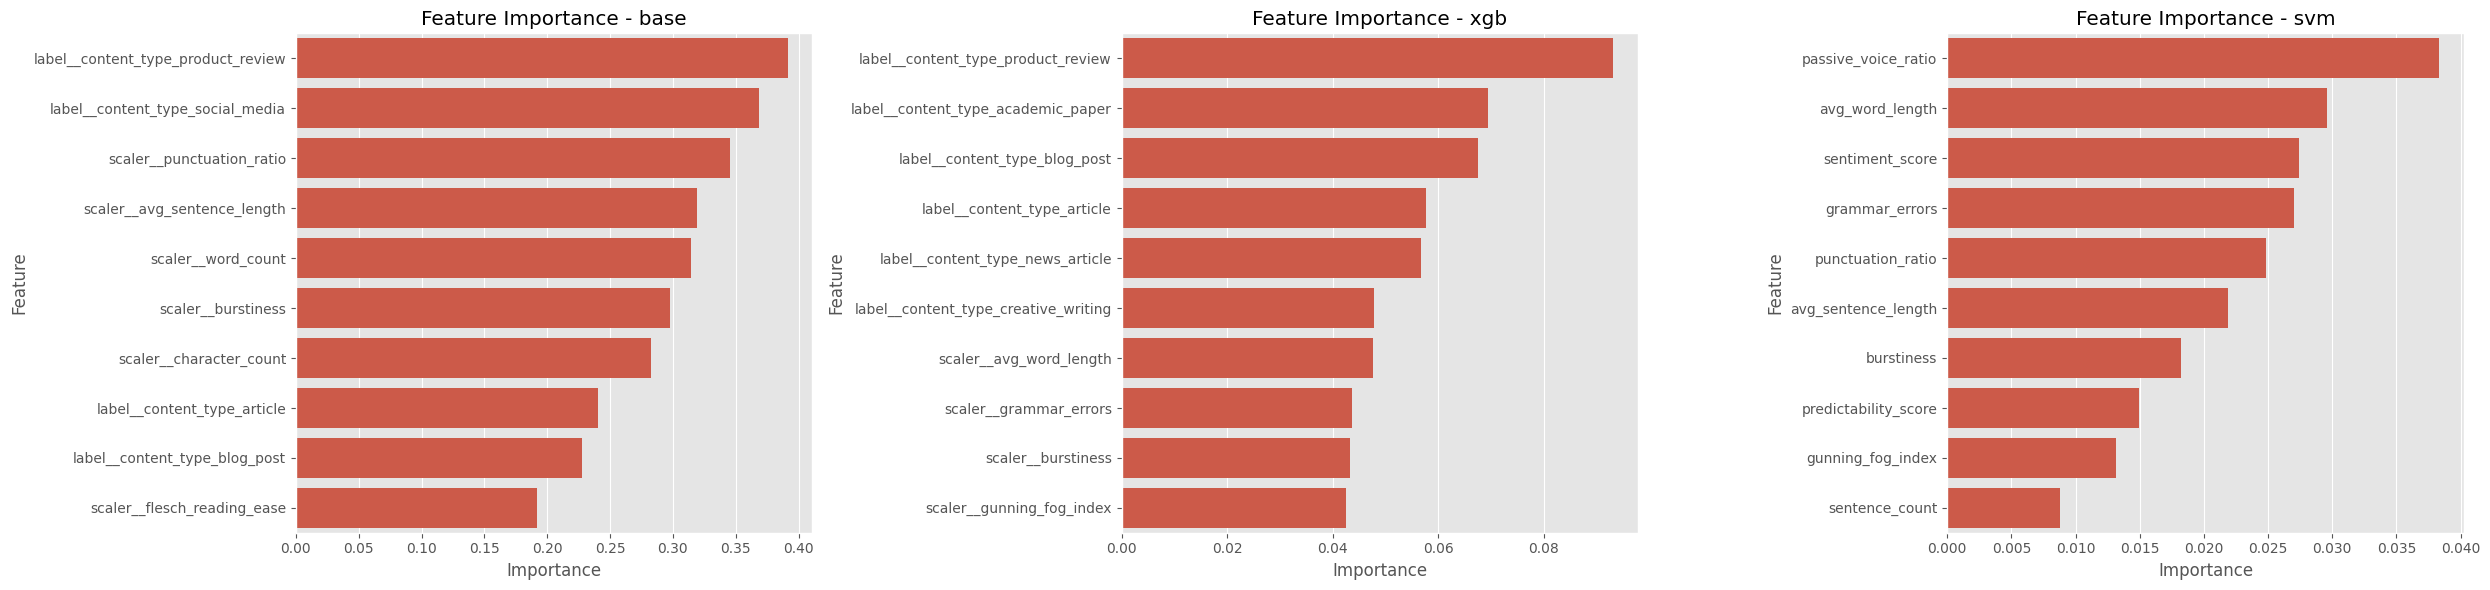

In [16]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 3, figsize=(25, 6))

feature_names_lr = models['base'].named_steps['preprocess'].get_feature_names_out()
feature_names_xgb = models['xgb'].named_steps['preprocess'].get_feature_names_out()
feature_names_svm = models['svm'].named_steps['preprocess'].get_feature_names_out()

importance_dict = {
    'base': (feature_names_lr, np.abs(models['base'].named_steps['model'].coef_[0])),
    'xgb': (feature_names_xgb, models['xgb'].named_steps['model'].feature_importances_),
    'svm': (X_test.columns.tolist(), permutation_importance(models['svm'], X_test, y_test, n_repeats=10, random_state=8).importances_mean)
}

for ax, (name, (feature_names, importances)) in zip(axes, importance_dict.items()):
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False).head(10)
    
    sns.barplot(data=fi_df, x='importance', y='feature', ax=ax)
    ax.set_title(f'Feature Importance - {name}')
    ax.set_xlabel('Importance')
    ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()


Report for base--------------------------------------------------
              precision    recall  f1-score   support

           0       0.46      0.45      0.45       137
           1       0.46      0.48      0.47       137

    accuracy                           0.46       274
   macro avg       0.46      0.46      0.46       274
weighted avg       0.46      0.46      0.46       274


Report for xgb--------------------------------------------------
              precision    recall  f1-score   support

           0       0.54      0.53      0.53       137
           1       0.54      0.54      0.54       137

    accuracy                           0.54       274
   macro avg       0.54      0.54      0.54       274
weighted avg       0.54      0.54      0.54       274


Report for svm--------------------------------------------------
              precision    recall  f1-score   support

           0       0.53      0.49      0.51       137
           1       0.52      0.56     

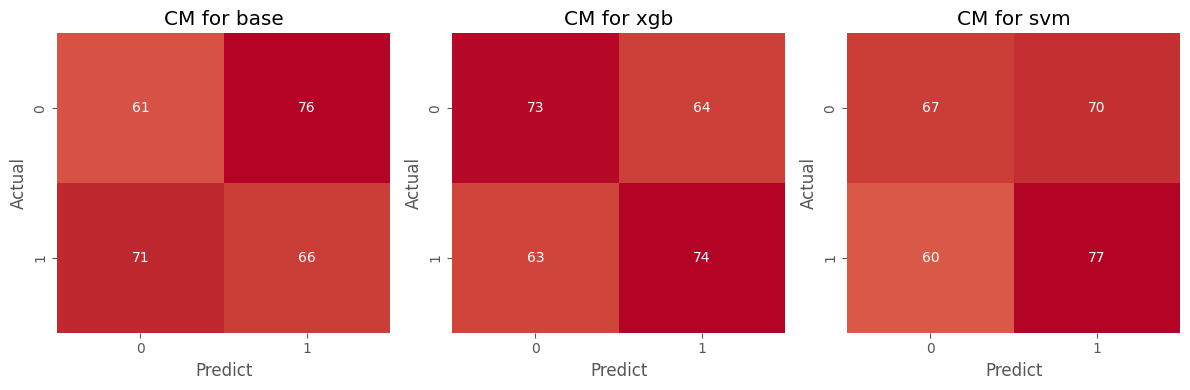

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

plt.figure(figsize= (12, 4))

for count, (name, y_pred) in enumerate(preds.items()):
    print(f'\nReport for {name}' + '-' * 50)

    print(classification_report(y_true= y_test, y_pred= y_pred))

    cm = confusion_matrix(y_true= y_test, y_pred= y_pred)

    plt.subplot(1, 3, count + 1)

    sns.heatmap(cm, cmap = 'coolwarm', center = 0, cbar = False,
                annot= True, fmt = 'd')
    plt.title(f'CM for {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predict')


plt.tight_layout()
plt.show()

### Results

The results are quite misserable, they are just random guessing

Let's try Vectorizing the actual text itself

In [18]:


X_text = df['text_content']
y = df['label']

X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y, test_size=0.2, random_state=8, stratify=y
)



In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf_models = {
    'base' : Pipeline([
        ('tfidf', TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85,
    strip_accents='unicode',
    lowercase=True,
    sublinear_tf=True,
    stop_words='english'
)),
        ('model', LogisticRegression())
    ]),

    'xgb' : Pipeline([
        ('tfidf', TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85,
    strip_accents='unicode',
    lowercase=True,
    sublinear_tf=True,
    stop_words='english'
)),
        ('model', XGBClassifier(
            n_estimators = 200,
            random_state = 8
        ))
    ]),

    'svm' : Pipeline([
        ('tfidf', TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85,
    strip_accents='unicode',
    lowercase=True,
    sublinear_tf=True,
    stop_words='english'
)),
        ('model', SVC(kernel='rbf', probability=True, random_state = 8))
    ]),
}

In [20]:
preds = {}

for name, model in tf_idf_models.items():
    print(f'Training and predicting {name} ----\n')
    model.fit(X_train_text, y_train_text)
    preds[name] = model.predict(X_test_text)



Training and predicting base ----

Training and predicting xgb ----

Training and predicting svm ----




Report for base--------------------------------------------------
              precision    recall  f1-score   support

           0       0.51      0.50      0.51       137
           1       0.51      0.52      0.51       137

    accuracy                           0.51       274
   macro avg       0.51      0.51      0.51       274
weighted avg       0.51      0.51      0.51       274


Report for xgb--------------------------------------------------
              precision    recall  f1-score   support

           0       0.47      0.53      0.50       137
           1       0.47      0.42      0.44       137

    accuracy                           0.47       274
   macro avg       0.47      0.47      0.47       274
weighted avg       0.47      0.47      0.47       274


Report for svm--------------------------------------------------
              precision    recall  f1-score   support

           0       0.51      0.53      0.52       137
           1       0.51      0.48     

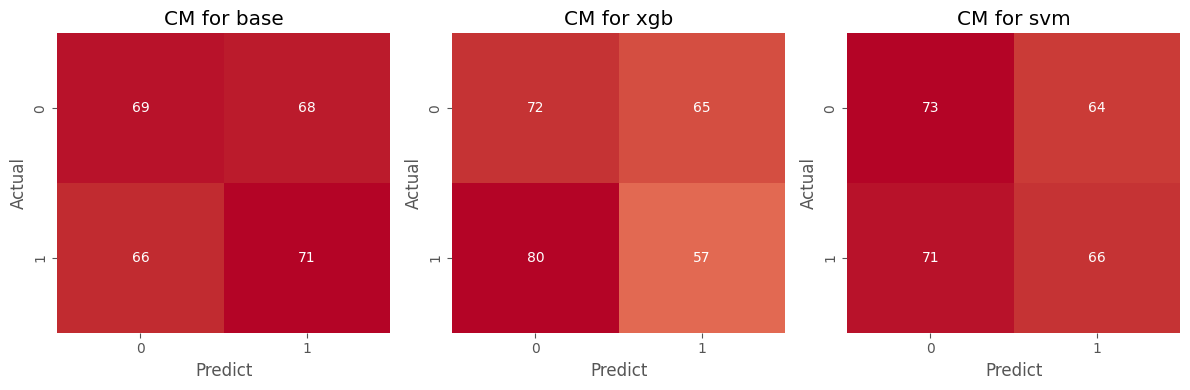

In [21]:
plt.figure(figsize= (12, 4))

for count, (name, y_pred) in enumerate(preds.items()):
    print(f'\nReport for {name}' + '-' * 50)

    print(classification_report(y_true= y_test_text, y_pred= y_pred))

    cm = confusion_matrix(y_true= y_test_text, y_pred= y_pred)

    plt.subplot(1, 3, count + 1)

    sns.heatmap(cm, cmap = 'coolwarm', center = 0, cbar = False,
                annot= True, fmt = 'd')
    plt.title(f'CM for {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predict')


plt.tight_layout()
plt.show()

The results are still quite bad, the next step is likely to combine both